# Lab: Funzione sigmoide e Regressione Logistica con scikit-learn

In questo notebook vediamo:

1. Cos’è la **sigmoide** e perché è utile per la **classificazione binaria**.
2. Perché nella regressione logistica si usa **z = w·x + b** (score lineare).
3. Come addestrare una **LogisticRegression** (scikit-learn) con **una sola variabile** e tracciare:
   - la curva di probabilità (P(y=1| x)\)
   - decision boundary (soglia 0.5)

Useremo librerie standard e scikit-learn.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score

%matplotlib inline


## 1) Sigmoide: da uno score qualsiasi a una probabilità

La sigmoide è:

sigma(z)=1/1+e^(-z)

Proprietà importanti:
- prende in input un numero qualsiasi z compreso tra -infinito e +infinito
- restituisce un valore tra 0 e 1 → lo possiamo interpretare come **probabilità**


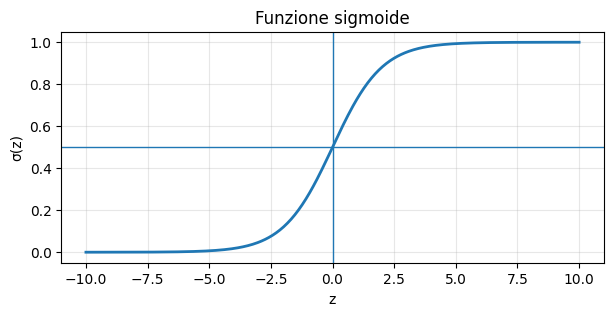

In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 400)
s = sigmoid(z)

plt.figure(figsize=(7,3))
plt.plot(z, s, linewidth=2)
plt.axhline(0.5, linewidth=1)
plt.axvline(0.0, linewidth=1)
plt.ylim(-0.05, 1.05)
plt.xlabel("z")
plt.ylabel("σ(z)")
plt.title("Funzione sigmoide")
plt.grid(True, alpha=0.3)
plt.show()


## 2) Perché si mette (z = w*x + b)?

Vogliamo modellare la probabilità:


P(y=1|x)

ma deve stare tra 0 e 1.

- Se usassimo direttamente una retta w*x + b, potremmo ottenere valori <0 o >1.
- Quindi usiamo uno **score lineare**:


z = w*x + b


e poi lo trasformiamo in probabilità con la sigmoide:


P(y=1| x) = sigma(w*x + b)


**Intuizione:**
- z grande positivo → probabilità vicina a 1
- z grande negativo → probabilità vicina a 0
- z=0 → probabilità 0.5


## 3) Dataset di esempio (1 feature)

Costruiamo un dataset semplicissimo:
- `x` è la variabile (una sola)
- `y` è la classe (0 o 1)

In un caso reale avresti molti più dati e rumore.


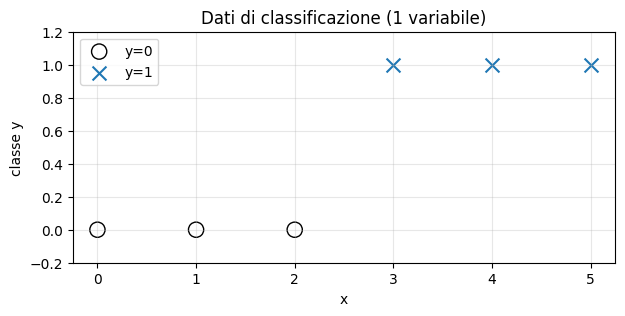

In [3]:
x = np.array([0., 1, 2, 3, 4, 5])
y = np.array([0,  0, 0, 1, 1, 1])

# scikit-learn vuole X come matrice (n_righe, n_feature)
X = x.reshape(-1, 1)

plt.figure(figsize=(7,3))
plt.scatter(x[y==0], y[y==0], s=120, facecolors="none", edgecolors="black", label="y=0")
plt.scatter(x[y==1], y[y==1], s=100, marker="x", label="y=1")
plt.ylim(-0.2, 1.2)
plt.xlabel("x")
plt.ylabel("classe y")
plt.title("Dati di classificazione (1 variabile)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 4) Addestramento con LogisticRegression (scikit-learn)

`LogisticRegression` stima i parametri \(w\) e \(b\) massimizzando la verosimiglianza
(equivalente a minimizzare la log-loss / cross-entropy).

Alla fine otteniamo:
- `coef_` → \(w\)
- `intercept_` → \(b\)


In [4]:
logreg = LogisticRegression()  # impostazioni di default (include regolarizzazione)
logreg.fit(X, y)

w = float(logreg.coef_[0][0])
b = float(logreg.intercept_[0])

print(f"w (coefficiente) = {w:.4f}")
print(f"b (intercetta)   = {b:.4f}")


w (coefficiente) = 1.1206
b (intercetta)   = -2.8018


## 5) Curva di probabilità P(y=1|x)

Tracciamo la probabilità stimata dal modello e vediamo anche la soglia 0.5.

La regola tipica è:
- se \(P > 0.5\) → predici classe 1
- altrimenti → predici classe 0


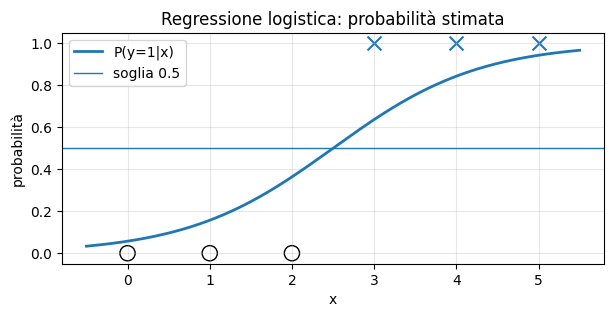

In [5]:
x_line = np.linspace(x.min()-0.5, x.max()+0.5, 400)
X_line = x_line.reshape(-1, 1)

proba_1 = logreg.predict_proba(X_line)[:, 1]

plt.figure(figsize=(7,3))
plt.plot(x_line, proba_1, linewidth=2, label="P(y=1|x)")
plt.axhline(0.5, linewidth=1, label="soglia 0.5")

# punti originali (y=0 e y=1)
plt.scatter(x[y==0], y[y==0], s=120, facecolors="none", edgecolors="black")
plt.scatter(x[y==1], y[y==1], s=100, marker="x")

plt.ylim(-0.05, 1.05)
plt.xlabel("x")
plt.ylabel("probabilità")
plt.title("Regressione logistica: probabilità stimata")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 6) Frontiera decisionale (decision boundary)

Con soglia 0.5, la frontiera è dove (P(y=1| x=0.5).

Con la sigmoide:
- \(P=0.5\) quando \(z = w x + b = 0\)

Quindi  la soglia su x è:


x= -b/w


x* (dove P=0.5) = 2.5002


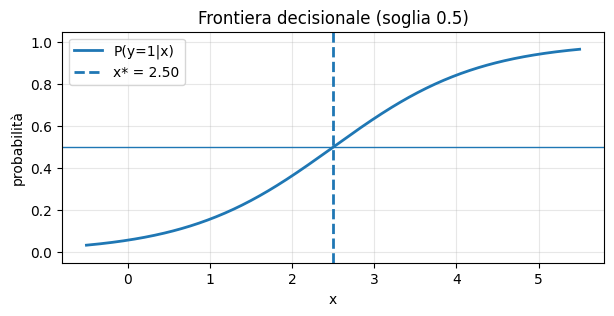

In [6]:
x_star = -b / w
print(f"x* (dove P=0.5) = {x_star:.4f}")

plt.figure(figsize=(7,3))
plt.plot(x_line, proba_1, linewidth=2, label="P(y=1|x)")
plt.axhline(0.5, linewidth=1)
plt.axvline(x_star, linewidth=2, linestyle="--", label=f"x* = {x_star:.2f}")

plt.ylim(-0.05, 1.05)
plt.xlabel("x")
plt.ylabel("probabilità")
plt.title("Frontiera decisionale (soglia 0.5)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 7) Valutazione veloce sul dataset

Calcoliamo:
- predizioni 0/1 sul dataset
- accuracy
- confusion matrix

(Con pochi punti è solo una demo.)


In [7]:
y_pred = logreg.predict(X)
y_proba = logreg.predict_proba(X)[:, 1]

acc = accuracy_score(y, y_pred)
cm = confusion_matrix(y, y_pred)

print("y_pred:", y_pred)
print(f"Accuracy: {acc:.3f}")
print("Confusion matrix:\n", cm)




y_pred: [0 0 0 1 1 1]
Accuracy: 1.000
Confusion matrix:
 [[3 0]
 [0 3]]


## 8) Conclusione (messaggio chiave)

- La parte **lineare** \(z = w x + b\) serve a costruire uno **score** semplice e interpretabile a partire dai dati.
- La **sigmoide** trasforma lo score in una **probabilità** tra 0 e 1.
- La regressione logistica è pensata per classificazione: ottimizza una loss adatta (log-loss) e produce output probabilistici.


## Esercizi

1. Aggiungi due punti “rumorosi” (es. un 1 in mezzo agli zeri o viceversa) e osserva come cambia la curva.  
2. Prova a cambiare `C` in `LogisticRegression(C=...)` e vedi l’effetto della regolarizzazione.  



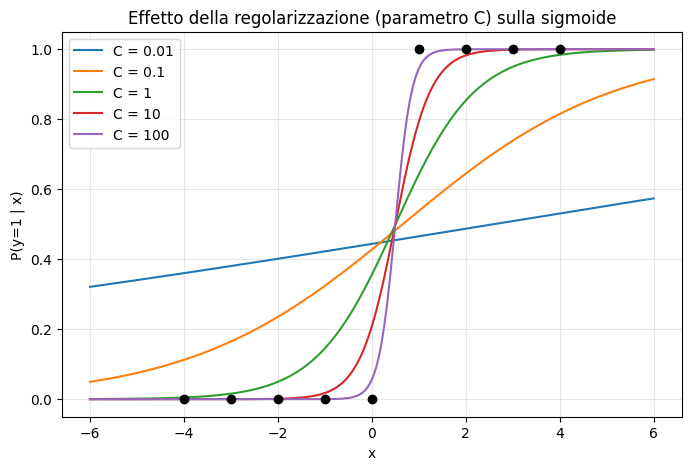

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Dataset semplice
X = np.array([-4, -3, -2, -1, 0, 1, 2, 3, 4]).reshape(-1,1)
y = np.array([0,0,0,0,0,1,1,1,1])

# Range continuo per disegnare la sigmoide
X_plot = np.linspace(-6, 6, 200).reshape(-1,1)

# diversi valori di C
C_values = [0.01, 0.1, 1, 10, 100]

plt.figure(figsize=(8,5))

for C in C_values:
    
    # QUI si trova il parametro C
    model = LogisticRegression(C=C)
    
    model.fit(X, y)
    
    # calcola probabilità
    proba = model.predict_proba(X_plot)[:,1]
    
    plt.plot(X_plot, proba, label=f"C = {C}")

# punti reali
plt.scatter(X, y, color="black", zorder=3)

plt.xlabel("x")
plt.ylabel("P(y=1 | x)")
plt.title("Effetto della regolarizzazione (parametro C) sulla sigmoide")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()
